# Exploratory Data Analysis (EDA)

This notebook explores **The Movies Dataset** (Kaggle -- rounakbanik) to understand
data distributions, user behaviour, and movie characteristics before modelling.

**Outputs:** EDA figures saved to `data/figures/`

**Key questions:**
- How are ratings distributed? Are users generous or critical?
- How active are users? Are most ratings from a small power-user group?
- Which genres dominate? Which are niche?
- How has rating activity changed over time?

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Import from src modules
import sys
sys.path.append('..')
from src.data import DataLoader
from src.visualization import Plotter

# Initialize data loader and plotter
data_loader = DataLoader()
plotter = Plotter()

print("Modules loaded successfully!")

Modules loaded successfully!


## Load Data

In [2]:
# Load data (sample for EDA)
ratings = data_loader.load_ratings(nrows=100000)
movies_metadata = data_loader.load_movies_metadata()
credits = data_loader.load_credits()
keywords = data_loader.load_keywords()
links = data_loader.load_links()

print(f"Ratings (sample): {ratings.shape}")
print(f"Movies Metadata: {movies_metadata.shape}")
print(f"Credits: {credits.shape}")
print(f"Keywords: {keywords.shape}")
print(f"Links: {links.shape}")

Ratings (sample): (100000, 4)
Movies Metadata: (45466, 24)
Credits: (45476, 3)
Keywords: (46419, 2)
Links: (45843, 3)


## Rating Distribution Analysis

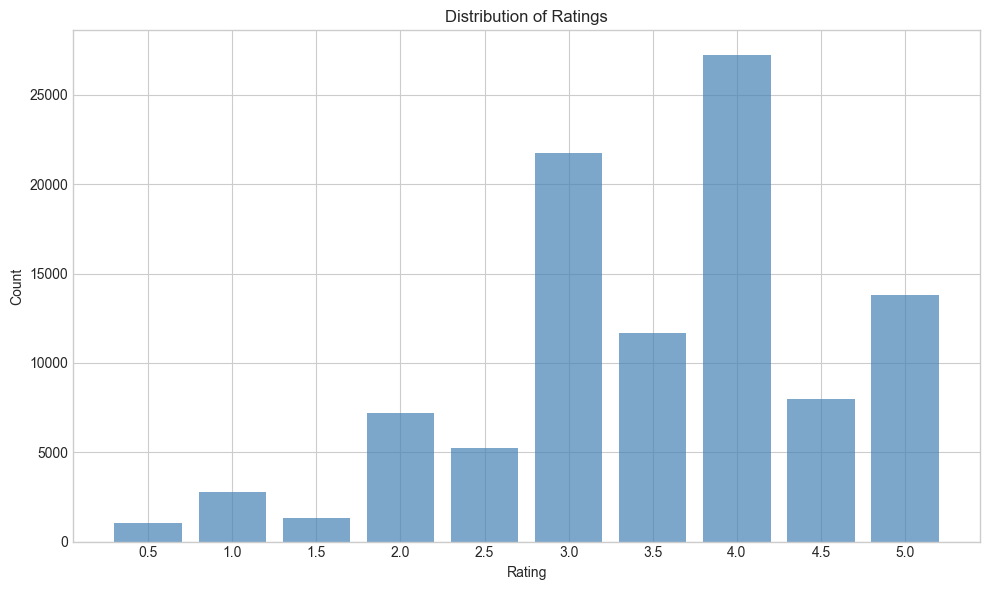

Rating Statistics:
Mean Rating: 3.53
Median Rating: 3.50
Std Rating: 1.02
Min Rating: 0.5
Max Rating: 5.0


In [3]:
# Plot rating distribution using Plotter
plotter.plot_rating_distribution(ratings, save=True)

print("Rating Statistics:")
print(f"Mean Rating: {ratings['rating'].mean():.2f}")
print(f"Median Rating: {ratings['rating'].median():.2f}")
print(f"Std Rating: {ratings['rating'].std():.2f}")
print(f"Min Rating: {ratings['rating'].min()}")
print(f"Max Rating: {ratings['rating'].max()}")

## User Activity Analysis

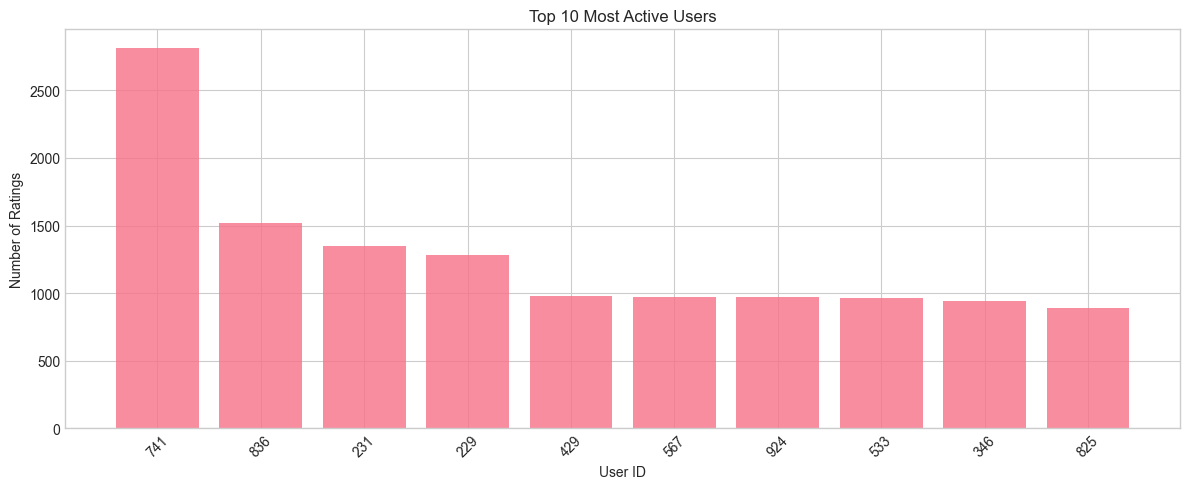

User Activity Summary
------------------------------
Total Users          : 1,014
Average Ratings/User : 98.62
Median Ratings/User  : 32.00


In [4]:
# Plot user activity using Plotter
plotter.plot_user_activity(ratings, save=True)

# Summary statistics
user_activity = ratings.groupby("userId").size()
print("User Activity Summary")
print("-" * 30)
print(f"Total Users          : {len(user_activity):,}")
print(f"Average Ratings/User : {user_activity.mean():.2f}")
print(f"Median Ratings/User  : {user_activity.median():.2f}")

## Movie Popularity Analysis

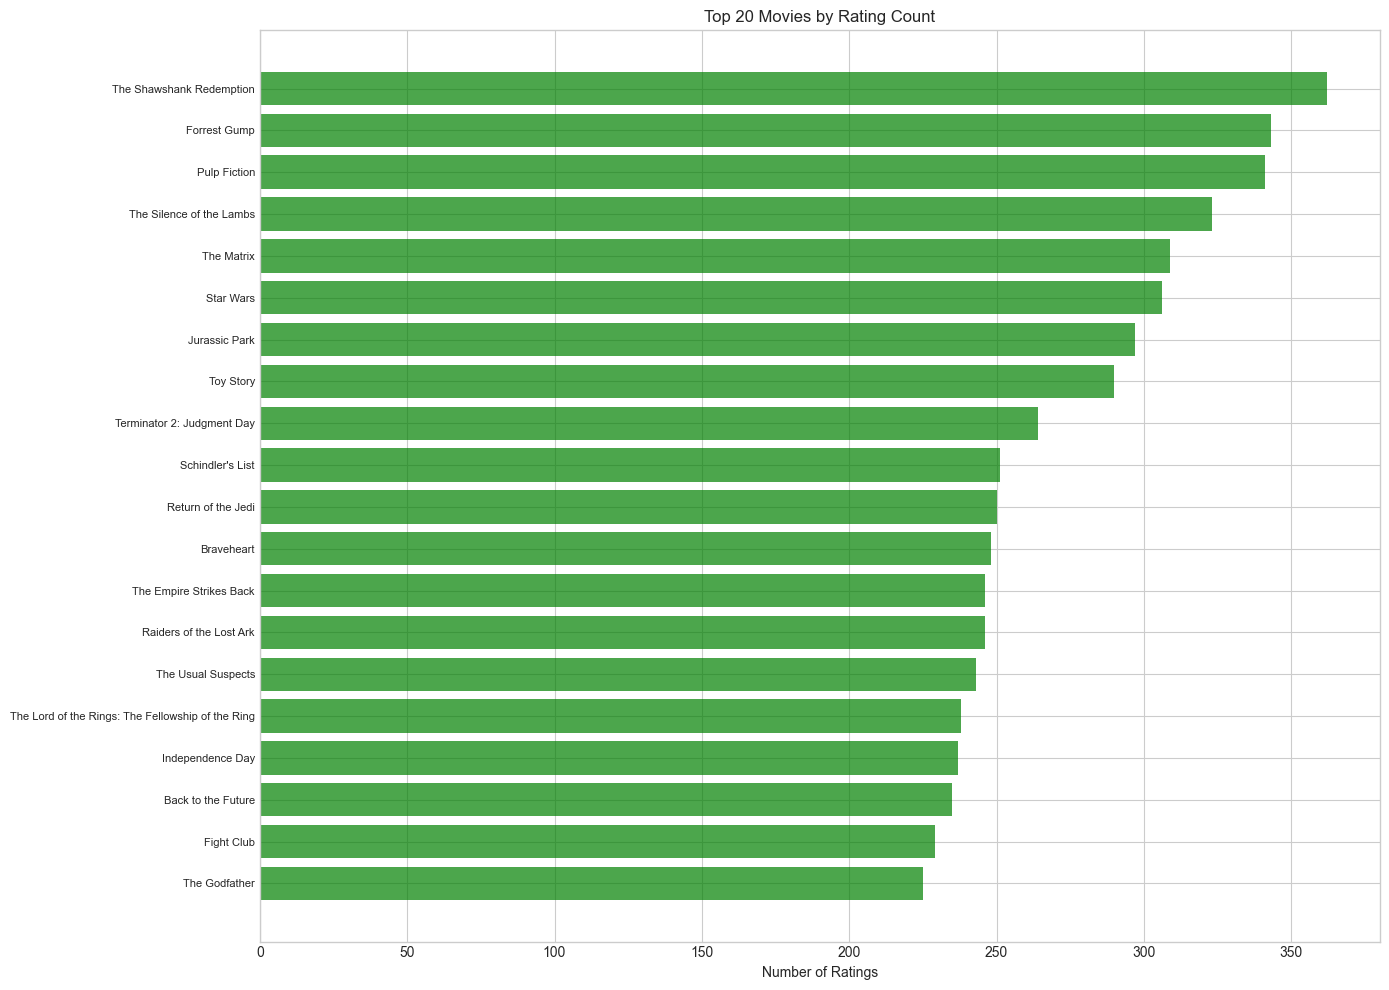

Movie Popularity Statistics:
Total Movies: 8,832
Mean Ratings per Movie: 11.32
Median Ratings per Movie: 3.00


In [5]:
# Plot movie popularity using Plotter
# Need to merge ratings with movies_metadata to get titles

movies_metadata['id'] = pd.to_numeric(
    movies_metadata['id'],
    errors='coerce'
)

links['tmdbId'] = pd.to_numeric(
    links['tmdbId'],
    errors='coerce'
)

movies_with_ratings = ratings.merge(links[['movieId', 'tmdbId']], on='movieId', how='left')
movies_with_ratings = movies_with_ratings.merge(
    movies_metadata[['id', 'title']], 
    left_on='tmdbId', 
    right_on='id', 
    how='left'
)
plotter.plot_movie_popularity(ratings, movies_with_ratings, save=True)

print("Movie Popularity Statistics:")
movie_popularity = ratings.groupby('movieId').size()
print(f"Total Movies: {len(movie_popularity):,}")
print(f"Mean Ratings per Movie: {movie_popularity.mean():.2f}")
print(f"Median Ratings per Movie: {movie_popularity.median():.2f}")

## Genre Distribution Analysis

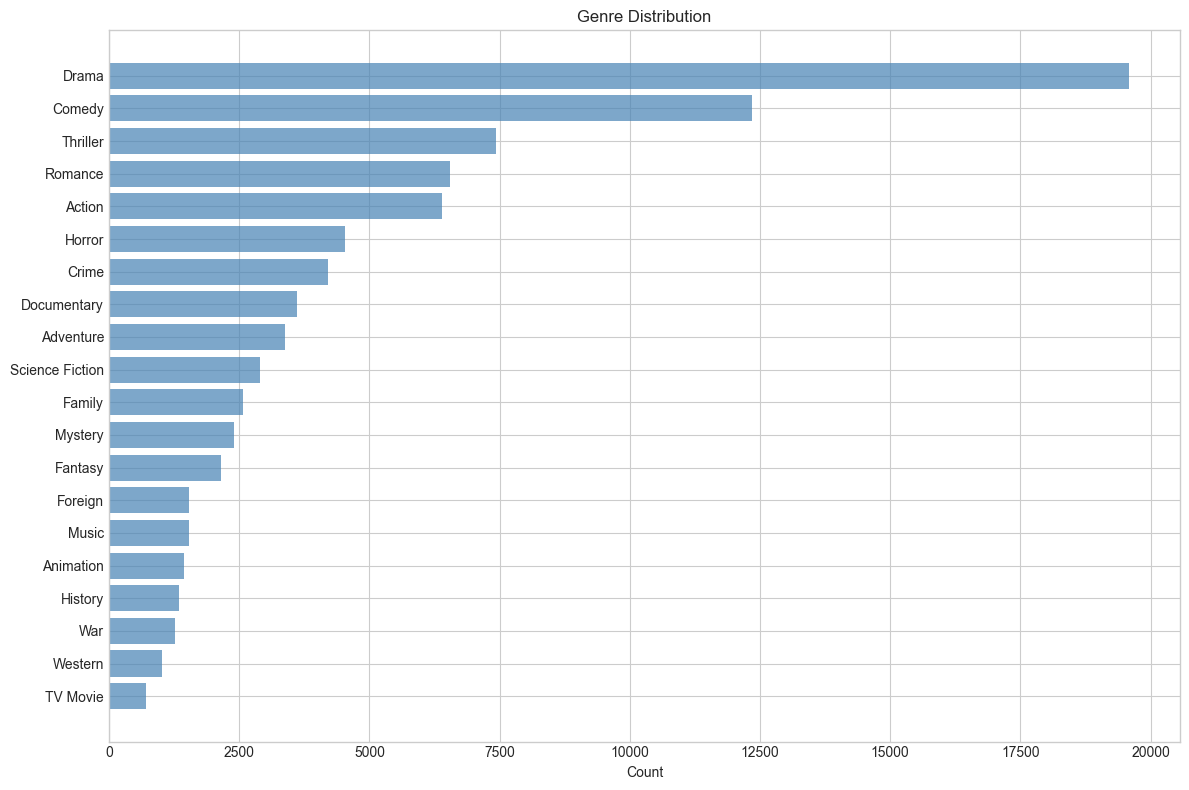

Genre Statistics:
Total Unique Genres: 20

Top 10 Genres:
Drama: 19,584
Comedy: 12,343
Thriller: 7,431
Romance: 6,552
Action: 6,390
Horror: 4,526
Crime: 4,202
Documentary: 3,601
Adventure: 3,383
Science Fiction: 2,895


In [6]:
# Plot genre distribution using Plotter
# Note: movies_metadata has genres in JSON format, need to parse first
from src.data import DataCleaner
cleaner = DataCleaner()
movies_clean = cleaner.clean_movies_metadata(movies_metadata)
plotter.plot_genre_distribution(movies_clean, save=True)

print("Genre Statistics:")
from collections import Counter
all_genres = []
for genre_names in movies_clean['genre_names'].dropna():
    if isinstance(genre_names, list):
        all_genres.extend(genre_names)
genre_counts = Counter(all_genres)
print(f"Total Unique Genres: {len(genre_counts)}")
print(f"\nTop 10 Genres:")
for genre, count in genre_counts.most_common(10):
    print(f"{genre}: {count:,}")

## Temporal Analysis

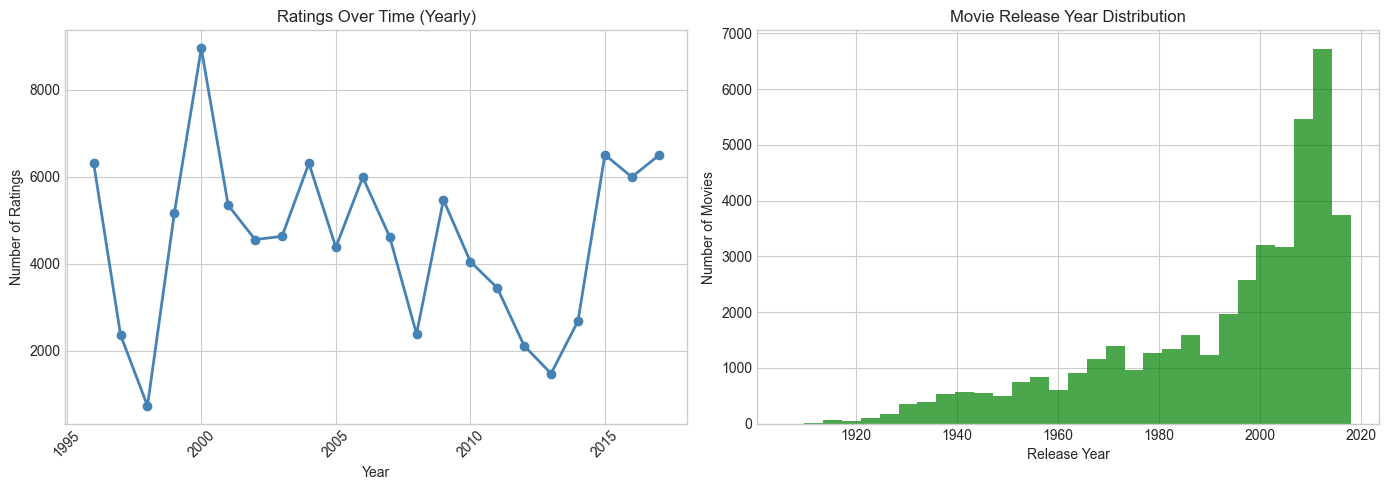

Temporal Statistics:
Rating Date Range: 1996-03-27 17:20:36 to 2017-08-04 04:52:46


In [7]:
# Plot temporal analysis using Plotter
plotter.plot_temporal_analysis(ratings, movies_clean, save=True)

print("Temporal Statistics:")
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['datetime'].dt.year
print(f"Rating Date Range: {ratings['datetime'].min()} to {ratings['datetime'].max()}")

## Sparsity Analysis

In [8]:
# Sparsity analysis
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)
total_possible = n_users * n_movies
sparsity = 1 - (n_ratings / total_possible)
density = n_ratings / total_possible

print("Sparsity Analysis:")
print(f"Total Users: {n_users:,}")
print(f"Total Movies: {n_movies:,}")
print(f"Total Ratings: {n_ratings:,}")
print(f"Total Possible Ratings: {total_possible:,}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
print(f"Density: {density:.4f} ({density*100:.2f}%)")
print(f"Average Ratings per User: {n_ratings/n_users:.2f}")
print(f"Average Ratings per Movie: {n_ratings/n_movies:.2f}")

Sparsity Analysis:
Total Users: 1,014
Total Movies: 8,832
Total Ratings: 100,000
Total Possible Ratings: 8,955,648
Sparsity: 0.9888 (98.88%)
Density: 0.0112 (1.12%)
Average Ratings per User: 98.62
Average Ratings per Movie: 11.32


## EDA Summary

In [9]:
# Create summary dataframe
summary_data = {
    'Metric': ['Total Users', 'Total Movies', 'Total Ratings', 'Sparsity', 'Avg Rating', 'Avg Ratings/User', 'Avg Ratings/Movie'],
    'Value': [n_users, n_movies, n_ratings, f"{sparsity:.4f}", f"{ratings['rating'].mean():.2f}", f"{n_ratings/n_users:.2f}", f"{n_ratings/n_movies:.2f}"]
}

summary_df = pd.DataFrame(summary_data)
print("EDA Summary:")
print(summary_df.to_string(index=False))

EDA Summary:
           Metric  Value
      Total Users   1014
     Total Movies   8832
    Total Ratings 100000
         Sparsity 0.9888
       Avg Rating   3.53
 Avg Ratings/User  98.62
Avg Ratings/Movie  11.32


## Key Findings

Results from the 100,000-rating sample (ratings_small.csv):

### Ratings
- Mean rating **3.53**, median **3.50**, std **1.02** -- slightly right-skewed (users tend positive)
- Range: 0.5 to 5.0 in 0.5-step increments
- Whole-number ratings (1, 2, 3, 4, 5) are more frequent than half-steps

### Users
- 1,014 users in the sample; average **98.6 ratings/user**, median **32**
- Strong right-skew: a small group of power users accounts for most ratings

### Movies
- 8,832 unique movies rated; mean **11.3 ratings/movie**, median **3** -- long-tail distribution
- Popular movies (blockbusters) have thousands of ratings; most have very few

### Genres
- 20 unique genres; Drama (19,584), Comedy (12,343), Thriller (7,431) dominate
- Foreign, Western, TV Movie are rare niches

### Temporal
- Ratings span 1996-03-27 to 2017-08-04
- Activity peaks in the mid-2000s and again around 2015

### Sparsity
- Matrix sparsity: **98.88%** (only 1.12% of possible user-movie pairs have a rating)
- This confirms collaborative filtering needs strong regularisation or SVD to generalise

In [10]:
print("EDA complete!")

EDA complete!
